# Fig7a_plot_evorates_PA_all_alpha

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch 


In [2]:
print('im getting all alpha by filtering out non-PA alpha from the below file')
log_file = "combined_log/evorates_PA_deer_other_deer/combined_log3" 

df = pd.read_csv(log_file, sep="\t", comment="#")
df

im getting all alpha by filtering out non-PA alpha from the below file


,state,joint,prior,likelihood,treeModel.rootHeight,age(root),treeLength,tmrca(WTD),tmrca(HomoSapiens),tmrca(deer_PA),...,02d_N_28274_29533_human_WTD_187_171_.Nmasked.covariance,02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.treeLikelihood,02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.treeLikelihood,02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.treeLikelihood,02d_N_28274_29533_human_WTD_187_171_.Nmasked.treeLikelihood,02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.branchRates,02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.branchRates,02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.branchRates,02d_N_28274_29533_human_WTD_187_171_.Nmasked.branchRates,coalescent
0,5000,-78253.901035,-1188.038424,-77065.862610,4.433366,2018.766634,98.343670,3.279744,4.433366,1.974099,...,0.991142,-10913.308882,-40175.544792,-21812.973911,-4164.035025,0.0,0.0,0.0,0.0,-1019.511489
1,10000,-74386.592502,-1210.551864,-73176.040638,4.566159,2018.633841,113.838055,2.642635,4.566159,1.978802,...,0.991848,-10395.025499,-38184.534964,-20636.753706,-3959.726469,0.0,0.0,0.0,0.0,-1149.075498
2,15000,-71245.825894,-1225.125204,-70020.700689,4.108631,2019.091369,129.913292,2.563679,4.108631,1.919781,...,0.991505,-10020.891317,-36476.540300,-19694.001166,-3829.267905,0.0,0.0,0.0,0.0,-1237.686768
3,20000,-69232.369665,-1230.045769,-68002.323896,4.128908,2019.071092,132.540239,2.588899,4.128908,1.919781,...,0.991486,-9744.848747,-35364.884638,-19170.199962,-3722.390549,0.0,0.0,0.0,0.0,-1264.049853
4,25000,-67825.801852,-1232.065768,-66593.736084,4.188082,2019.011918,129.831552,2.392953,4.188082,1.982954,...,0.991775,-9552.070130,-34629.919405,-18768.994108,-3642.752441,0.0,0.0,0.0,0.0,-1270.438471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61320,306605000,-53125.838748,-769.909268,-52355.929480,3.957744,2019.242256,65.659583,2.472283,3.957744,1.979746,...,0.991204,-7695.598826,-26997.702832,-14907.341195,-2755.286628,0.0,0.0,0.0,0.0,-821.740887
61321,306610000,-53131.203112,-771.398292,-52359.804819,3.959168,2019.240832,66.338123,2.527662,3.959168,1.951838,...,0.989585,-7691.927018,-26985.513884,-14927.402109,-2754.961808,0.0,0.0,0.0,0.0,-823.671490
61322,306615000,-53118.688651,-755.935903,-52362.752749,3.932412,2019.267588,64.062337,2.527662,3.932412,1.984436,...,0.992256,-7681.367862,-27003.106181,-14922.255680,-2756.023026,0.0,0.0,0.0,0.0,-807.608578
61323,306620000,-53099.055469,-735.620341,-52363.435128,3.968901,2019.231099,62.906463,2.531522,3.968901,1.938790,...,0.989918,-7691.686733,-26999.078413,-14921.300801,-2751.369180,0.0,0.0,0.0,0.0,-789.271268


In [3]:
df.columns

Index(['state', 'joint', 'prior', 'likelihood', 'treeModel.rootHeight',
       'age(root)', 'treeLength', 'tmrca(WTD)', 'tmrca(HomoSapiens)',
       'tmrca(deer_PA)', 'age(WTD)', 'age(HomoSapiens)', 'age(deer_PA)',
       'constant.popSize',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.kappa',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies1',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies2',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies3',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies4',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.alpha',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.kappa',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies1',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies2',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies3',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies4

xticks not shown but MUST match other figures evo rates
setting yticks MUST match other evo rates figs


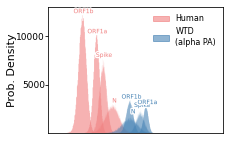

In [27]:
import matplotlib.patheffects as pe

# ── 2. COLUMN NAMES ───────────────────────────────────────────────────────


columns_wtd_PA = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.deer_PA.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.deer_PA.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.deer_PA.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.deer_PA.rate'
}

columns_clock = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.clock.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.clock.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.clock.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.clock.rate'
}

# ── 3. COLOURS FOR HUMAN AND WTD ──────────────────────────────────────────
human_color = 'lightcoral'
wtd_PA_color   = 'steelblue'

# ── 4. SINGLE PLOT ────────────────────────────────────────────────────────
plt.figure(figsize=(3.3, 2.1))
ax = plt.gca()


human_handle = None
wtd_PA_handle = None

# text outline for readability
stroke = [pe.withStroke(linewidth=2.5, foreground="white")]

for gene in ["Spike", "N", "ORF1a", "ORF1b"]:
    if gene in columns_wtd_PA and gene in columns_clock and \
        columns_wtd_PA[gene] in df.columns and columns_clock[gene] in df.columns:

        
        wtd_PA_data   = df[columns_wtd_PA[gene]].values
        human_data = df[columns_clock[gene]].values


        bins = np.linspace(
            min(wtd_PA_data.min(), human_data.min()),
            max(wtd_PA_data.max(), human_data.max()),
            5000
        )

        # Human
        h_counts, h_edges, _ = plt.hist(
            human_data, bins=bins, color=human_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if human_handle is None:
            human_handle = Patch(color=human_color, alpha=0.6, label='Human')


        # WTD Y2
        w_Y2_counts, w_Y2_edges, _ = plt.hist(
            wtd_PA_data, bins=bins, color=wtd_PA_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_PA_handle is None:
            wtd_PA_handle = Patch(color=wtd_PA_color, alpha=0.6, label='WTD PA')
            
            
        # ── 5. LABELS NEAR PEAKS (x = mean, y = peak height) ───────────────
        h_mean = np.mean(human_data)
        w_Y2_mean = np.mean(wtd_PA_data)

        h_peak = h_counts.max()
        w_Y2_peak = w_Y2_counts.max()

        # small vertical nudge so text sits above the peak
        ax.text(h_mean * 1.01, h_peak * 1.01, gene,
                ha='center', va='bottom', color=human_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y2_mean * 1.04, w_Y2_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_PA_color,
                fontsize=6, path_effects=stroke, clip_on=True)

#plt.xlabel("substitutions/site/year",fontsize=11)
plt.ylabel("Prob. Density", fontsize = 11,labelpad=-1)
plt.xscale("log")
plt.xlim(1e-4, 2e-2)
plt.ylim(0,13000)
ax.xaxis.set_minor_locator(plt.NullLocator())

def scientific_formatter(x, pos):
    s = f"{x:.0e}".replace('e+00', '').replace('e-0', 'e-').replace('e', 'x10^')
    return s

formatter = FuncFormatter(scientific_formatter)
ax.xaxis.set_major_formatter(formatter)


print('xticks not shown but MUST match other figures evo rates')
#plt.xticks([2e-4, 1e-3, 4e-3,2e-2],
#           labels=['2e-4', '1e-3', '4e-3','2e-2'], fontsize=9)
plt.xticks([])

print('setting yticks MUST match other evo rates figs')
plt.yticks([5000, 10000],
           labels=['5000', '10000'], fontsize=9)
ax.yaxis.set_tick_params(pad=0.0001)



plt.legend(handles=[human_handle, wtd_PA_handle],
           labels=['Human', 'WTD\n(alpha PA)'],
           loc='upper right', frameon=False, fontsize=8)

plt.tight_layout()
plt.savefig('./evorates_all_alpha.png',format='png',dpi=600,bbox_inches='tight')

# Fig7a_plot_evorates_PA_deer_other_deer

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch 


In [2]:

log_file = "combined_log/evorates_PA_deer_other_deer/combined_log3" 

df = pd.read_csv(log_file, sep="\t", comment="#")
df

,state,joint,prior,likelihood,treeModel.rootHeight,age(root),treeLength,tmrca(WTD),tmrca(HomoSapiens),tmrca(deer_PA),...,02d_N_28274_29533_human_WTD_187_171_.Nmasked.covariance,02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.treeLikelihood,02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.treeLikelihood,02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.treeLikelihood,02d_N_28274_29533_human_WTD_187_171_.Nmasked.treeLikelihood,02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.branchRates,02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.branchRates,02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.branchRates,02d_N_28274_29533_human_WTD_187_171_.Nmasked.branchRates,coalescent
0,5000,-78253.901035,-1188.038424,-77065.862610,4.433366,2018.766634,98.343670,3.279744,4.433366,1.974099,...,0.991142,-10913.308882,-40175.544792,-21812.973911,-4164.035025,0.0,0.0,0.0,0.0,-1019.511489
1,10000,-74386.592502,-1210.551864,-73176.040638,4.566159,2018.633841,113.838055,2.642635,4.566159,1.978802,...,0.991848,-10395.025499,-38184.534964,-20636.753706,-3959.726469,0.0,0.0,0.0,0.0,-1149.075498
2,15000,-71245.825894,-1225.125204,-70020.700689,4.108631,2019.091369,129.913292,2.563679,4.108631,1.919781,...,0.991505,-10020.891317,-36476.540300,-19694.001166,-3829.267905,0.0,0.0,0.0,0.0,-1237.686768
3,20000,-69232.369665,-1230.045769,-68002.323896,4.128908,2019.071092,132.540239,2.588899,4.128908,1.919781,...,0.991486,-9744.848747,-35364.884638,-19170.199962,-3722.390549,0.0,0.0,0.0,0.0,-1264.049853
4,25000,-67825.801852,-1232.065768,-66593.736084,4.188082,2019.011918,129.831552,2.392953,4.188082,1.982954,...,0.991775,-9552.070130,-34629.919405,-18768.994108,-3642.752441,0.0,0.0,0.0,0.0,-1270.438471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61320,306605000,-53125.838748,-769.909268,-52355.929480,3.957744,2019.242256,65.659583,2.472283,3.957744,1.979746,...,0.991204,-7695.598826,-26997.702832,-14907.341195,-2755.286628,0.0,0.0,0.0,0.0,-821.740887
61321,306610000,-53131.203112,-771.398292,-52359.804819,3.959168,2019.240832,66.338123,2.527662,3.959168,1.951838,...,0.989585,-7691.927018,-26985.513884,-14927.402109,-2754.961808,0.0,0.0,0.0,0.0,-823.671490
61322,306615000,-53118.688651,-755.935903,-52362.752749,3.932412,2019.267588,64.062337,2.527662,3.932412,1.984436,...,0.992256,-7681.367862,-27003.106181,-14922.255680,-2756.023026,0.0,0.0,0.0,0.0,-807.608578
61323,306620000,-53099.055469,-735.620341,-52363.435128,3.968901,2019.231099,62.906463,2.531522,3.968901,1.938790,...,0.989918,-7691.686733,-26999.078413,-14921.300801,-2751.369180,0.0,0.0,0.0,0.0,-789.271268


In [3]:
df.columns

Index(['state', 'joint', 'prior', 'likelihood', 'treeModel.rootHeight',
       'age(root)', 'treeLength', 'tmrca(WTD)', 'tmrca(HomoSapiens)',
       'tmrca(deer_PA)', 'age(WTD)', 'age(HomoSapiens)', 'age(deer_PA)',
       'constant.popSize',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.kappa',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies1',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies2',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies3',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies4',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.alpha',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.kappa',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies1',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies2',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies3',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies4

xticks not shown but MUST match other figures evo rates
setting yticks MUST match other evo rates figs


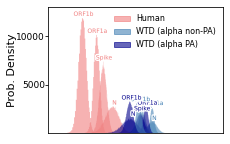

In [10]:
import matplotlib.patheffects as pe

# ── 2. COLUMN NAMES ───────────────────────────────────────────────────────
columns_wtd_Y1 = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.WTD.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.WTD.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.WTD.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.WTD.rate'
}

columns_wtd_Y2 = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.deer_PA.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.deer_PA.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.deer_PA.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.deer_PA.rate'
}

columns_clock = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.clock.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.clock.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.clock.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.clock.rate'
}

# ── 3. COLOURS FOR HUMAN AND WTD ──────────────────────────────────────────
human_color = 'lightcoral'
wtd_Y1_color   = 'steelblue'
wtd_Y2_color   = 'darkblue'

# ── 4. SINGLE PLOT ────────────────────────────────────────────────────────
plt.figure(figsize=(3.3, 2.1))
ax = plt.gca()

human_handle = None
wtd_Y1_handle = None
wtd_Y2_handle = None

# text outline for readability
stroke = [pe.withStroke(linewidth=2.5, foreground="white")]

for gene in ["Spike", "N", "ORF1a", "ORF1b"]:
    if gene in columns_wtd_Y1 and gene in columns_wtd_Y2 and gene in columns_clock and \
       columns_wtd_Y1[gene] in df.columns and columns_wtd_Y2[gene] in df.columns and columns_clock[gene] in df.columns:

        wtd_Y1_data   = df[columns_wtd_Y1[gene]].values
        wtd_Y2_data   = df[columns_wtd_Y2[gene]].values
        human_data = df[columns_clock[gene]].values


        bins = np.linspace(
            min(wtd_Y1_data.min(), wtd_Y2_data.min(), human_data.min()),
            max(wtd_Y1_data.max(), wtd_Y2_data.max(), human_data.max()),
            5000
        )

        # Human
        h_counts, h_edges, _ = plt.hist(
            human_data, bins=bins, color=human_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if human_handle is None:
            human_handle = Patch(color=human_color, alpha=0.6, label='Human')

        # WTD Y1
        w_Y1_counts, w_Y1_edges, _ = plt.hist(
            wtd_Y1_data, bins=bins, color=wtd_Y1_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_Y1_handle is None:
            wtd_Y1_handle = Patch(color=wtd_Y1_color, alpha=0.6, label='WTD Non-PA States')

        # WTD Y2
        w_Y2_counts, w_Y2_edges, _ = plt.hist(
            wtd_Y2_data, bins=bins, color=wtd_Y2_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_Y2_handle is None:
            wtd_Y2_handle = Patch(color=wtd_Y2_color, alpha=0.6, label='WTD PA')
            
            
        # ── 5. LABELS NEAR PEAKS (x = mean, y = peak height) ───────────────
        h_mean = np.mean(human_data)
        w_Y1_mean = np.mean(wtd_Y1_data)
        w_Y2_mean = np.mean(wtd_Y2_data)

        h_peak = h_counts.max()
        w_Y1_peak = w_Y1_counts.max()
        w_Y2_peak = w_Y2_counts.max()

        # small vertical nudge so text sits above the peak
        ax.text(h_mean * 1.01, h_peak * 1.01, gene,
                ha='center', va='bottom', color=human_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y1_mean * 1.04, w_Y1_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_Y1_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y2_mean * 1.04, w_Y2_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_Y2_color,
                fontsize=6, path_effects=stroke, clip_on=True)

#plt.xlabel("substitutions/site/year",fontsize=11)
plt.ylabel("Prob. Density", fontsize = 11,labelpad=-1)
plt.xscale("log")
plt.xlim(1e-4, 2e-2)
plt.ylim(0,13000)
ax.xaxis.set_minor_locator(plt.NullLocator())

def scientific_formatter(x, pos):
    s = f"{x:.0e}".replace('e+00', '').replace('e-0', 'e-').replace('e', 'x10^')
    return s

formatter = FuncFormatter(scientific_formatter)
ax.xaxis.set_major_formatter(formatter)

print('xticks not shown but MUST match other figures evo rates')
#plt.xticks([2e-4, 1e-3, 4e-3,2e-2],
#           labels=['2e-4', '1e-3', '4e-3','2e-2'], fontsize=9)
plt.xticks([])
print('setting yticks MUST match other evo rates figs')
plt.yticks([5000, 10000],
           labels=['5000', '10000'], fontsize=9)
ax.yaxis.set_tick_params(pad=0.0001)


plt.legend(handles=[human_handle, wtd_Y1_handle, wtd_Y2_handle],
           labels=['Human', 'WTD (alpha non-PA)', 'WTD (alpha PA)'],
           loc='upper right', frameon=False, fontsize=8)

plt.tight_layout()

plt.savefig('./evorates_PA_deer_other_deer.png',format='png',dpi=600,bbox_inches='tight')

# Fig7a_PA_alpha_Y1_Y2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch 


In [2]:

log_file = "combined_log/evorates_PA_Y1Y2_other_deer/combined_log1" 

df = pd.read_csv(log_file, sep="\t", comment="#")
df

,state,joint,prior,likelihood,treeModel.rootHeight,age(root),treeLength,tmrca(Y1_PA),tmrca(WTD),tmrca(Y2_PA),...,02d_N_28274_29533_human_WTD_187_171_.Nmasked.covariance,02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.treeLikelihood,02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.treeLikelihood,02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.treeLikelihood,02d_N_28274_29533_human_WTD_187_171_.Nmasked.treeLikelihood,02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.branchRates,02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.branchRates,02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.branchRates,02d_N_28274_29533_human_WTD_187_171_.Nmasked.branchRates,coalescent
0,10000,-73587.983931,-1013.328554,-72574.655378,3.775284,2019.424716,82.243338,2.037351,2.447944,2.214145,...,0.992379,-10415.238837,-37605.368807,-20571.002644,-3983.045090,0.0,0.0,0.0,0.0,-958.190418
1,20000,-68447.200093,-1060.433394,-67386.766699,3.654866,2019.545134,99.376254,2.412341,2.445464,2.185422,...,0.991685,-9728.284607,-35041.732973,-18946.161396,-3670.587723,0.0,0.0,0.0,0.0,-1099.194794
2,30000,-66176.098873,-1036.068125,-65140.030748,3.694015,2019.505985,96.783778,1.972176,2.430311,2.031379,...,0.992297,-9422.342928,-33951.208083,-18250.640634,-3515.839104,0.0,0.0,0.0,0.0,-1089.839901
3,40000,-63965.345208,-1046.959344,-62918.385865,3.880408,2019.319592,96.562102,1.972176,2.436887,2.042927,...,0.991475,-9121.970465,-32773.860986,-17634.687720,-3387.866694,0.0,0.0,0.0,0.0,-1106.127394
4,50000,-62253.495044,-1042.312084,-61211.182960,3.880055,2019.319945,96.610765,1.972539,2.436887,2.042927,...,0.985705,-8883.838116,-31851.265846,-17176.952635,-3299.126362,0.0,0.0,0.0,0.0,-1107.264037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64039,640400000,-53099.913694,-699.437265,-52400.476430,3.671584,2019.528416,60.090053,1.781826,2.437172,1.733635,...,0.967311,-7688.860979,-27024.156539,-14921.352479,-2766.106432,0.0,0.0,0.0,0.0,-767.139392
64040,640410000,-53114.854334,-696.245445,-52418.608890,3.868994,2019.331006,59.815220,1.786923,2.418776,1.618444,...,0.966887,-7693.156276,-27015.916129,-14951.860422,-2757.676063,0.0,0.0,0.0,0.0,-767.851868
64041,640420000,-53117.748599,-711.877030,-52405.871569,4.010278,2019.189722,61.212084,1.788456,2.449268,1.696672,...,0.983750,-7687.912716,-27026.839334,-14929.882369,-2761.237150,0.0,0.0,0.0,0.0,-784.429968
64042,640430000,-53137.609558,-734.379184,-52403.230374,3.832786,2019.367214,63.183807,1.796797,2.442150,1.689639,...,0.979809,-7687.780538,-27017.739439,-14928.141061,-2769.569336,0.0,0.0,0.0,0.0,-807.952136


In [3]:
[col for col in df.columns if '.rate' in col]

['02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.clock.rate',
 '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.Y1_PA.rate',
 '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.WTD.rate',
 '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.Y2_PA.rate',
 '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.clock.rate',
 '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.Y1_PA.rate',
 '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.WTD.rate',
 '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.Y2_PA.rate',
 '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.clock.rate',
 '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.Y1_PA.rate',
 '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.WTD.rate',
 '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.Y2_PA.rate',
 '02d_N_28274_29533_human_WTD_187_171_.Nmasked.clock.rate',
 '02d_N_28274_29533_human_WTD_187_171_.Nmasked.Y1_PA.rate',
 '02d_N_28274_29533_human_WTD_187_171_.Nmasked.WTD.rate',
 '02d_N_28274_29533_human_WTD_187_171_.Nmasked.Y2_PA.rate']

xticks in other figs shown
setting yticks MUST match other evo rates figs


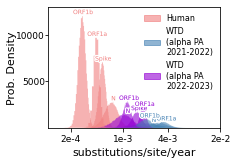

In [12]:
import matplotlib.patheffects as pe

# ── 2. COLUMN NAMES ───────────────────────────────────────────────────────
columns_wtd_Y1 = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.Y1_PA.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.Y1_PA.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.Y1_PA.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.Y1_PA.rate'
}

columns_wtd_Y2 = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.Y2_PA.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.Y2_PA.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.Y2_PA.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.Y2_PA.rate'
}

columns_clock = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.clock.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.clock.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.clock.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.clock.rate'
}

# ── 3. COLOURS FOR HUMAN AND WTD ──────────────────────────────────────────
human_color = 'lightcoral'
wtd_Y1_color   = 'steelblue'
wtd_Y2_color   = 'darkviolet'

# ── 4. SINGLE PLOT ────────────────────────────────────────────────────────
plt.figure(figsize=(3.4, 2.4))
ax = plt.gca()

human_handle = None
wtd_Y1_handle = None
wtd_Y2_handle = None

# text outline for readability
stroke = [pe.withStroke(linewidth=2.5, foreground="white")]

for gene in ["Spike", "N", "ORF1a", "ORF1b"]:
    if gene in columns_wtd_Y1 and gene in columns_wtd_Y2 and gene in columns_clock and \
       columns_wtd_Y1[gene] in df.columns and columns_wtd_Y2[gene] in df.columns and columns_clock[gene] in df.columns:

        wtd_Y1_data   = df[columns_wtd_Y1[gene]].values
        wtd_Y2_data   = df[columns_wtd_Y2[gene]].values
        human_data = df[columns_clock[gene]].values


        bins = np.linspace(
            min(wtd_Y1_data.min(), wtd_Y2_data.min(), human_data.min()),
            max(wtd_Y1_data.max(), wtd_Y2_data.max(), human_data.max()),
            1000
        )

        # Human
        h_counts, h_edges, _ = plt.hist(
            human_data, bins=bins, color=human_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if human_handle is None:
            human_handle = Patch(color=human_color, alpha=0.6, label='Human')

        # WTD Y1
        w_Y1_counts, w_Y1_edges, _ = plt.hist(
            wtd_Y1_data, bins=bins, color=wtd_Y1_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_Y1_handle is None:
            wtd_Y1_handle = Patch(color=wtd_Y1_color, alpha=0.6, label='WTD Y1')

        # WTD Y2
        w_Y2_counts, w_Y2_edges, _ = plt.hist(
            wtd_Y2_data, bins=bins, color=wtd_Y2_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_Y2_handle is None:
            wtd_Y2_handle = Patch(color=wtd_Y2_color, alpha=0.6, label='WTD Y2')
            
            
        # ── 5. LABELS NEAR PEAKS (x = mean, y = peak height) ───────────────
        h_mean = np.mean(human_data)
        w_Y1_mean = np.mean(wtd_Y1_data)
        w_Y2_mean = np.mean(wtd_Y2_data)

        h_peak = h_counts.max()
        w_Y1_peak = w_Y1_counts.max()
        w_Y2_peak = w_Y2_counts.max()

        # small vertical nudge so text sits above the peak
        ax.text(h_mean * 1.01, h_peak * 1.01, gene,
                ha='center', va='bottom', color=human_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y1_mean * 1.04, w_Y1_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_Y1_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y2_mean * 1.04, w_Y2_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_Y2_color,
                fontsize=6, path_effects=stroke, clip_on=True)

plt.xlabel("substitutions/site/year",fontsize=11)
plt.ylabel("Prob. Density", fontsize = 11,labelpad=-1)
plt.xscale("log")
plt.xlim(1e-4, 2e-2)
plt.ylim(0,13000)
ax.xaxis.set_minor_locator(plt.NullLocator())

def scientific_formatter(x, pos):
    s = f"{x:.0e}".replace('e+00', '').replace('e-0', 'e-').replace('e', 'x10^')
    return s

formatter = FuncFormatter(scientific_formatter)
ax.xaxis.set_major_formatter(formatter)
print('xticks in other figs shown')
plt.xticks([2e-4, 1e-3, 4e-3,2e-2],
           labels=['2e-4', '1e-3', '4e-3','2e-2'], fontsize=9)

print('setting yticks MUST match other evo rates figs')
plt.yticks([5000, 10000],
           labels=['5000', '10000'], fontsize=9)
ax.yaxis.set_tick_params(pad=0.0001)

plt.legend(handles=[human_handle, wtd_Y1_handle, wtd_Y2_handle],
           labels=['Human', 'WTD\n(alpha PA\n2021-2022)', 'WTD\n(alpha PA\n2022-2023)'],
           loc='upper right', frameon=False, fontsize=8)

plt.tight_layout()

plt.savefig('./evorates_all_PA_alpha_Y1_Y2.png',format='png',dpi=600,bbox_inches='tight')

# Fig7a_plot_evorates_PA_cluster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from matplotlib.ticker import FuncFormatter
from matplotlib.patches import Patch 


In [2]:

log_file = "combined_log/evorates_PA_cluster/combined_log3" 

df = pd.read_csv(log_file, sep="\t", comment="#")
df

,state,joint,prior,likelihood,treeModel.rootHeight,age(root),treeLength,tmrca(OtherDeer),tmrca(1),tmrca(2),...,02d_N_28274_29533_human_WTD_187_171_.Nmasked.covariance,02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.treeLikelihood,02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.treeLikelihood,02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.treeLikelihood,02d_N_28274_29533_human_WTD_187_171_.Nmasked.treeLikelihood,02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.branchRates,02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.branchRates,02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.branchRates,02d_N_28274_29533_human_WTD_187_171_.Nmasked.branchRates,coalescent
0,10000,-72909.726869,-1149.508074,-71760.218795,4.478029,2018.721971,125.418270,4.067294,3.874300,2.732328,...,0.989325,-10010.676336,-37504.914309,-20268.227023,-3976.401127,0.0,0.0,0.0,0.0,-1173.991021
1,20000,-68348.273251,-1160.514838,-67187.758414,4.221401,2018.978599,139.023955,2.763792,3.874300,2.232156,...,0.991641,-9432.141735,-35167.410280,-18877.362199,-3710.844200,0.0,0.0,0.0,0.0,-1266.334115
2,30000,-65721.487573,-1189.339024,-64532.148549,4.591319,2018.608681,149.395572,2.626927,3.717271,1.227266,...,0.991706,-9198.476733,-33583.375287,-18233.714126,-3516.582403,0.0,0.0,0.0,0.0,-1307.941146
3,40000,-63952.013231,-1208.045298,-62743.967932,4.427243,2018.772757,154.622902,3.104016,3.697894,1.544793,...,0.991573,-8973.232974,-32698.621538,-17674.779855,-3397.333565,0.0,0.0,0.0,0.0,-1333.747695
4,50000,-62609.623315,-1223.510592,-61386.112723,4.872620,2018.327380,156.055892,3.104016,3.828269,1.289717,...,0.991997,-8806.347268,-31925.278558,-17307.500198,-3346.986700,0.0,0.0,0.0,0.0,-1349.514404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52053,520540000,-52869.587067,-637.745674,-52231.841393,3.584496,2019.615504,60.956289,2.529392,1.810295,0.749572,...,0.991643,-7670.560837,-26957.172195,-14845.517664,-2758.590697,0.0,0.0,0.0,0.0,-759.542314
52054,520550000,-52871.859418,-656.213555,-52215.645864,3.634584,2019.565416,61.438643,2.485024,1.741388,0.677306,...,0.948451,-7667.608967,-26943.577035,-14853.319499,-2751.140362,0.0,0.0,0.0,0.0,-775.827557
52055,520560000,-52863.589471,-647.870036,-52215.719435,4.027755,2019.172245,62.121641,2.463288,1.763767,0.705947,...,0.990782,-7667.139696,-26937.767731,-14853.315563,-2757.496444,0.0,0.0,0.0,0.0,-770.981399
52056,520570000,-52883.152658,-659.700039,-52223.452618,3.624398,2019.575602,62.042509,2.450327,1.776523,0.775313,...,0.988701,-7678.792356,-26936.091146,-14851.407255,-2757.161861,0.0,0.0,0.0,0.0,-775.963857


In [3]:
df.columns

Index(['state', 'joint', 'prior', 'likelihood', 'treeModel.rootHeight',
       'age(root)', 'treeLength', 'tmrca(OtherDeer)', 'tmrca(1)', 'tmrca(2)',
       'tmrca(3)', 'tmrca(5)', 'tmrca(HomoSapiens)', 'age(OtherDeer)',
       'age(1)', 'age(2)', 'age(3)', 'age(5)', 'age(HomoSapiens)',
       'constant.popSize',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.kappa',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies1',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies2',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies3',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.frequencies4',
       '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.alpha',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.kappa',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies1',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequencies2',
       '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.frequenci

xticks not shown but MUST match other figures evo rates
setting yticks MUST match other evo rates figs


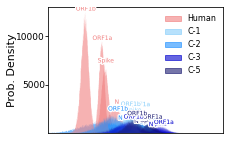

In [7]:
import matplotlib.patheffects as pe

# ── 2. COLUMN NAMES ───────────────────────────────────────────────────────
columns_wtd_Y1 = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.1.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.1.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.1.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.1.rate'
}

columns_wtd_Y2 = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.2.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.2.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.2.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.2.rate'
}


columns_wtd_Y3 = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.3.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.3.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.3.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.3.rate'
}


columns_wtd_Y5 = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.5.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.5.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.5.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.5.rate'
}

columns_clock = {
    "Spike": '02a_SPIKE_21563_25384_human_WTD_187_171_.Nmasked.clock.rate',
    "N":     '02d_N_28274_29533_human_WTD_187_171_.Nmasked.clock.rate',
    'ORF1a': '02b_ORF1a_266_13468_human_WTD_187_171_.Nmasked.clock.rate',
    'ORF1b': '02c_ORF1b_13468_21555_human_WTD_187_171_.Nmasked.clock.rate'
}

# ── 3. COLOURS FOR HUMAN AND WTD ──────────────────────────────────────────
human_color = 'lightcoral'
wtd_Y1_color   = 'lightskyblue'#'steelblue'
wtd_Y2_color   = 'dodgerblue'
wtd_Y3_color   = 'mediumblue'
wtd_Y5_color   = 'midnightblue'

# ── 4. SINGLE PLOT ────────────────────────────────────────────────────────
plt.figure(figsize=(3.3, 2.1))
ax = plt.gca()

human_handle = None
wtd_Y1_handle = None
wtd_Y2_handle = None
wtd_Y3_handle = None
wtd_Y5_handle = None

# text outline for readability
stroke = [pe.withStroke(linewidth=2.5, foreground="white")]

for gene in ["Spike", "N", "ORF1a", "ORF1b"]:
    if gene in columns_wtd_Y1 and gene in columns_wtd_Y2 and gene in columns_wtd_Y3 and gene in columns_wtd_Y5 and \
       gene in columns_clock and \
       columns_wtd_Y1[gene] in df.columns and columns_wtd_Y2[gene] in df.columns and \
       columns_wtd_Y3[gene] in df.columns and columns_wtd_Y5[gene] in df.columns and \
       columns_clock[gene] in df.columns:

        wtd_Y1_data   = df[columns_wtd_Y1[gene]].values
        wtd_Y2_data   = df[columns_wtd_Y2[gene]].values
        wtd_Y3_data   = df[columns_wtd_Y3[gene]].values
        wtd_Y5_data   = df[columns_wtd_Y5[gene]].values
        human_data = df[columns_clock[gene]].values


        bins = np.linspace(
            min(wtd_Y1_data.min(), wtd_Y2_data.min(), wtd_Y3_data.min(), wtd_Y5_data.min(), human_data.min()),
            max(wtd_Y1_data.max(), wtd_Y2_data.max(), wtd_Y3_data.max(), wtd_Y5_data.max(), human_data.max()),
            5000
        )

        # Human
        h_counts, h_edges, _ = plt.hist(
            human_data, bins=bins, color=human_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if human_handle is None:
            human_handle = Patch(color=human_color, alpha=0.6, label='Human')

        # WTD Y1
        w_Y1_counts, w_Y1_edges, _ = plt.hist(
            wtd_Y1_data, bins=bins, color=wtd_Y1_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_Y1_handle is None:
            wtd_Y1_handle = Patch(color=wtd_Y1_color, alpha=0.6, label='C-1')

        # WTD Y2
        w_Y2_counts, w_Y2_edges, _ = plt.hist(
            wtd_Y2_data, bins=bins, color=wtd_Y2_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_Y2_handle is None:
            wtd_Y2_handle = Patch(color=wtd_Y2_color, alpha=0.6, label='C-2')
            
        # WTD Y3
        w_Y3_counts, w_Y3_edges, _ = plt.hist(
            wtd_Y3_data, bins=bins, color=wtd_Y3_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_Y3_handle is None:
            wtd_Y3_handle = Patch(color=wtd_Y3_color, alpha=0.6, label='C-3')
            
        # WTD Y5
        w_Y5_counts, w_Y5_edges, _ = plt.hist(
            wtd_Y5_data, bins=bins, color=wtd_Y5_color, alpha=0.6,
            histtype='stepfilled', density=True
        )
        if wtd_Y5_handle is None:
            wtd_Y5_handle = Patch(color=wtd_Y5_color, alpha=0.6, label='C-5')
            
            
        # ── 5. LABELS NEAR PEAKS (x = mean, y = peak height) ───────────────
        h_mean = np.mean(human_data)
        w_Y1_mean = np.mean(wtd_Y1_data)
        w_Y2_mean = np.mean(wtd_Y2_data)
        w_Y3_mean = np.mean(wtd_Y3_data)
        w_Y5_mean = np.mean(wtd_Y5_data)

        h_peak = h_counts.max()
        w_Y1_peak = w_Y1_counts.max()
        w_Y2_peak = w_Y2_counts.max()
        w_Y3_peak = w_Y3_counts.max()
        w_Y5_peak = w_Y5_counts.max()

        # small vertical nudge so text sits above the peak
        ax.text(h_mean * 1.01, h_peak * 1.01, gene,
                ha='center', va='bottom', color=human_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y1_mean * 1.04, w_Y1_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_Y1_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y2_mean * 1.04, w_Y2_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_Y2_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y3_mean * 1.04, w_Y3_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_Y3_color,
                fontsize=6, path_effects=stroke, clip_on=True)
        ax.text(w_Y5_mean * 1.04, w_Y5_peak * 1.01, gene,
                ha='center', va='bottom', color=wtd_Y5_color,
                fontsize=6, path_effects=stroke, clip_on=True)

#plt.xlabel("substitutions/site/year",fontsize=11)
plt.ylabel("Prob. Density", fontsize = 11,labelpad=-1)
plt.xscale("log")
plt.xlim(1e-4, 2e-2)
plt.ylim(0,13000)
ax.xaxis.set_minor_locator(plt.NullLocator())

def scientific_formatter(x, pos):
    s = f"{x:.0e}".replace('e+00', '').replace('e-0', 'e-').replace('e', 'x10^')
    return s

formatter = FuncFormatter(scientific_formatter)
ax.xaxis.set_major_formatter(formatter)

print('xticks not shown but MUST match other figures evo rates')
#plt.xticks([1e-4, 4e-4, 3e-3,1.5e-2],
#           labels=['1e-4', '4e-4', '3e-3','1.5e-2'], fontsize=9)
#plt.xticks([2e-4, 1e-3, 4e-3,2e-2],
#           labels=['2e-4', '1e-3', '4e-3','2e-2'], fontsize=9)
plt.xticks([])

print('setting yticks MUST match other evo rates figs')
plt.yticks([5000, 10000],
           labels=['5000', '10000'], fontsize=9)
ax.yaxis.set_tick_params(pad=0.0001)



plt.legend(handles=[human_handle, wtd_Y1_handle, wtd_Y2_handle, wtd_Y3_handle, wtd_Y5_handle],
           labels=['Human', 'C-1', 'C-2', 'C-3', 'C-5'],
           loc='upper right', frameon=False, fontsize=8)

plt.tight_layout()

plt.savefig('./evorates_PA_cluster.png',format='png',dpi=600,bbox_inches='tight')

# Figure 7b

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import MaxNLocator
from matplotlib import gridspec

from Bio import SeqIO

# collect data for four partitions

## Spike

In [ ]:
csv_path_spike = '03_SPIKE_only_all_alpha_PA_nextclade.aligned_AA_substitutions_cleaned.csv'
sequences_sc2_spike = pd.read_csv(csv_path_spike)

subs_df_spike  = pd.read_csv(csv_path_spike)
subs_df_spike["Substitutions"] = subs_df_spike["Substitutions"].fillna("")

# (Optional) keep the original sample ordering, if you defined one
try:
    sample_order = downstream_seqs          # defined earlier in the NB
    subs_df_spike      = subs_df_spike.set_index("Sample").loc[sample_order].reset_index()
except NameError:
    sample_order = subs_df_spike["Sample"].tolist()

# -----------------------------------------------------------------
# 1) BUILD A SAMPLE × POSITION GRID (spike_df_spike) WITH MUTATION CODES
# -----------------------------------------------------------------
all_pos   = set()
spike_map_spike = {s: {} for s in sample_order}   # sample → {pos: code}

for _, row in subs_df_spike.iterrows():
    sample = row["Sample"]
    for code in filter(None, map(str.strip, row["Substitutions"].split(","))):
        # e.g. "L5F"  →  pos = 5
        pos = int(re.sub(r"[A-Z]", "", code))
        all_pos.add(pos)
        spike_map_spike[sample][pos] = code       # keep the actual code (L5F)

positions_spike = sorted(all_pos)                # numeric Spike positions_spike

# empty-string grid (for imshow mask)
spike_df_spike = pd.DataFrame(
    "",
    index=sample_order,
    columns=positions_spike,
    dtype=object
)
for sample, d in spike_map_spike.items():
    for pos, code in d.items():
        spike_df_spike.at[sample, pos] = code

# -----------------------------------------------------------------
# 2) FIGURE — IDENTICAL LAYOUT AS ORIGINAL NOTEBOOK
# -----------------------------------------------------------------
pos_counts_spike   = (spike_df_spike != "").sum(axis=0)          # bar-plot counts
del spike_map_spike

In [3]:
spike_df_spike

,5,12,18,49,75,77,83,95,98,138,...,935,938,978,982,1020,1117,1208,1219,1247,1263
hCoV-19/deer/USA/PA-22-000890-017/2021|EPI_ISL_16297230|2021-12-02,,,,,,,,,,,...,,,,,,,,,,
hCoV-19/deer/USA/PA-22-000890-014/2021|EPI_ISL_16297229|2021-12-06,,,,,,,,,,,...,,,,,,,,V1219G,,
hCoV-19/deer/USA/PA-22-000890-030/2021|EPI_ISL_16297232|2021-12-06,,,,,,,,,,,...,,,,,,,,V1219G,,
hCoV-19/deer/USA/PA-21-038768-002/2021|EPI_ISL_9347719|2021-11-28,L5F,,,,,,,,,,...,,,,,,T1117I,,V1219G,,
hCoV-19/deer/USA/PA-VSP3516/2021|EPI_ISL_9651200|2021-10-22,,,,,,,,,S98F,D138H,...,,,,,,,,V1219G,,
hCoV-19/deer/USA/PA-VSP3574/2021|EPI_ISL_9654444|2021-11-27,,,,,,,,,,,...,,,,,,,,V1219G,,
hCoV-19/white-tailed_deer/USA/PA-23-015645-001/2022|EPI_ISL_17851798|2022-10-24,L5F,,,,,,,,,,...,Q935R,,,A982S,A1020S,,,V1219G,,
hCoV-19/deer/USA/PA-VSP30426/2022|EPI_ISL_19259471|2022-11-10,,,,,,,,,,,...,Q935R,,,,A1020S,,,V1219G,,
hCoV-19/deer/USA/PA-VSP30136/2022|EPI_ISL_19259475|2022-12-28,,,,,,,,,,,...,Q935R,,,,A1020S,,,V1219G,,
hCoV-19/deer/USA/PA-VSP30422/2022|EPI_ISL_19259486|2022-11-09,,,,,,,,,,,...,,,,,A1020S,,,V1219G,,


## ORF1a

In [ ]:
csv_path_ORF1a = '03_ORF1a_all_alpha_PA_nextclade.aligned_AA_substitutions_cleaned.csv'
sequences_sc2_ORF1a = pd.read_csv(csv_path_ORF1a)

subs_df_ORF1a  = pd.read_csv(csv_path_ORF1a)
subs_df_ORF1a["Substitutions"] = subs_df_ORF1a["Substitutions"].fillna("")

# (Optional) keep the original sample ordering, if you defined one
try:
    sample_order = downstream_seqs          # defined earlier in the NB
    subs_df_ORF1a      = subs_df_ORF1a.set_index("Sample").loc[sample_order].reset_index()
except NameError:
    sample_order = subs_df_ORF1a["Sample"].tolist()

# -----------------------------------------------------------------
# 1) BUILD A SAMPLE × POSITION GRID (spike_df_ORF1a) WITH MUTATION CODES
# -----------------------------------------------------------------
all_pos   = set()
spike_map_ORF1a = {s: {} for s in sample_order}   # sample → {pos: code}

for _, row in subs_df_ORF1a.iterrows():
    sample = row["Sample"]
    for code in filter(None, map(str.strip, row["Substitutions"].split(","))):
        # e.g. "L5F"  →  pos = 5
        pos = int(re.sub(r"[A-Z]", "", code))
        all_pos.add(pos)
        spike_map_ORF1a[sample][pos] = code       # keep the actual code (L5F)

positions_ORF1a = sorted(all_pos)                # numeric Spike positions_ORF1a

# empty-string grid (for imshow mask)
spike_df_ORF1a = pd.DataFrame(
    "",
    index=sample_order,
    columns=positions_ORF1a,
    dtype=object
)
for sample, d in spike_map_ORF1a.items():
    for pos, code in d.items():
        spike_df_ORF1a.at[sample, pos] = code

# -----------------------------------------------------------------
# 2) FIGURE — IDENTICAL LAYOUT AS ORIGINAL NOTEBOOK
# -----------------------------------------------------------------
pos_counts_ORF1a   = (spike_df_ORF1a != "").sum(axis=0)          # bar-plot counts
del spike_map_ORF1a

In [5]:
spike_df_ORF1a

,105,121,184,212,238,489,514,547,607,668,...,3725,3749,3772,3775,3800,3829,4031,4083,4111,4175
hCoV-19/deer/USA/PA-22-000890-017/2021|EPI_ISL_16297230|2021-12-02,,,,,,,,,,,...,,,,,,,,,,
hCoV-19/deer/USA/PA-22-000890-014/2021|EPI_ISL_16297229|2021-12-06,,,,,,,,,,,...,,,,,,L3829F,,,,
hCoV-19/deer/USA/PA-22-000890-030/2021|EPI_ISL_16297232|2021-12-06,,,,,,,,,,,...,N3725S,,,,,L3829F,,,,
hCoV-19/deer/USA/PA-21-038768-002/2021|EPI_ISL_9347719|2021-11-28,,,,,,,,,,,...,,,,,,L3829F,,,,
hCoV-19/deer/USA/PA-VSP3516/2021|EPI_ISL_9651200|2021-10-22,,,,,I238V,,,,,,...,,T3749I,T3772I,,,,,,L4111F,
hCoV-19/deer/USA/PA-VSP3574/2021|EPI_ISL_9654444|2021-11-27,,,,,,,,,,,...,,,,,,L3829F,,,,
hCoV-19/white-tailed_deer/USA/PA-23-015645-001/2022|EPI_ISL_17851798|2022-10-24,,,,,,,,,,,...,,,,,L3800F,L3829F,,,,
hCoV-19/deer/USA/PA-VSP30426/2022|EPI_ISL_19259471|2022-11-10,,,,,,,,I547M,,,...,,,,,L3800F,L3829F,,,L4111F,T4175I
hCoV-19/deer/USA/PA-VSP30136/2022|EPI_ISL_19259475|2022-12-28,,,,,,,,,,,...,,,,,L3800F,L3829F,,,,T4175I
hCoV-19/deer/USA/PA-VSP30422/2022|EPI_ISL_19259486|2022-11-09,,,,,,,,,,,...,,,,,L3800F,L3829F,,,,


## ORF1b

In [ ]:
csv_path_ORF1b = './03_ORF1b_all_alpha_PA_nextclade.aligned_AA_substitutions_cleaned.csv'
sequences_sc2_ORF1b = pd.read_csv(csv_path_ORF1b)

subs_df_ORF1b  = pd.read_csv(csv_path_ORF1b)
subs_df_ORF1b["Substitutions"] = subs_df_ORF1b["Substitutions"].fillna("")

# (Optional) keep the original sample ordering, if you defined one
try:
    sample_order = downstream_seqs          # defined earlier in the NB
    subs_df_ORF1b      = subs_df_ORF1b.set_index("Sample").loc[sample_order].reset_index()
except NameError:
    sample_order = subs_df_ORF1b["Sample"].tolist()

# -----------------------------------------------------------------
# 1) BUILD A SAMPLE × POSITION GRID (spike_df_ORF1b) WITH MUTATION CODES
# -----------------------------------------------------------------
all_pos   = set()
spike_map_ORF1b = {s: {} for s in sample_order}   # sample → {pos: code}

for _, row in subs_df_ORF1b.iterrows():
    sample = row["Sample"]
    for code in filter(None, map(str.strip, row["Substitutions"].split(","))):
        # e.g. "L5F"  →  pos = 5
        pos = int(re.sub(r"[A-Z]", "", code))
        all_pos.add(pos)
        spike_map_ORF1b[sample][pos] = code       # keep the actual code (L5F)

positions_ORF1b = sorted(all_pos)                # numeric Spike positions_ORF1b

# empty-string grid (for imshow mask)
spike_df_ORF1b = pd.DataFrame(
    "",
    index=sample_order,
    columns=positions_ORF1b,
    dtype=object
)
for sample, d in spike_map_ORF1b.items():
    for pos, code in d.items():
        spike_df_ORF1b.at[sample, pos] = code

# -----------------------------------------------------------------
# 2) FIGURE — IDENTICAL LAYOUT AS ORIGINAL NOTEBOOK
# -----------------------------------------------------------------
pos_counts_ORF1b   = (spike_df_ORF1b != "").sum(axis=0)          # bar-plot counts
del spike_map_ORF1b

In [7]:
spike_df_ORF1b

,54,218,220,376,520,545,582,617,813,1067,...,2339,2357,2359,2363,2376,2383,2414,2432,2537,2613
hCoV-19/deer/USA/PA-22-000890-017/2021|EPI_ISL_16297230|2021-12-02,,,,,,,,,,,...,,,,,,,,,,
hCoV-19/deer/USA/PA-22-000890-014/2021|EPI_ISL_16297229|2021-12-06,,,,,,,,,,,...,S2339F,,,,,,,,T2537I,
hCoV-19/deer/USA/PA-22-000890-030/2021|EPI_ISL_16297232|2021-12-06,,,,,,,,,,,...,S2339F,,,,,,,,T2537I,
hCoV-19/deer/USA/PA-21-038768-002/2021|EPI_ISL_9347719|2021-11-28,,L218P,,,,,,,,T1067I,...,,,,,,,,T2432I,,
hCoV-19/deer/USA/PA-VSP3516/2021|EPI_ISL_9651200|2021-10-22,,L218P,,,,,,,,,...,,,,,,,,,,
hCoV-19/deer/USA/PA-VSP3574/2021|EPI_ISL_9654444|2021-11-27,,,,,,,,,,,...,S2339F,,,,,,,,T2537I,
hCoV-19/white-tailed_deer/USA/PA-23-015645-001/2022|EPI_ISL_17851798|2022-10-24,,,,,,,T582I,,,,...,,,,,,,M2414I,T2432I,,
hCoV-19/deer/USA/PA-VSP30426/2022|EPI_ISL_19259471|2022-11-10,,,,,,,T582I,,,,...,,,,,,,M2414I,T2432I,,
hCoV-19/deer/USA/PA-VSP30136/2022|EPI_ISL_19259475|2022-12-28,,,,,,,T582I,,,,...,,,S2359F,,,,M2414I,T2432I,,
hCoV-19/deer/USA/PA-VSP30422/2022|EPI_ISL_19259486|2022-11-09,,,,,,,T582I,,,,...,,,S2359F,,,,M2414I,T2432I,,


## N

In [ ]:
csv_path_N = './03_N_only_all_alpha_PA_nextclade.aligned_AA_substitutions_cleaned.csv'
sequences_sc2_N = pd.read_csv(csv_path_N)

subs_df_N  = pd.read_csv(csv_path_N)
subs_df_N["Substitutions"] = subs_df_N["Substitutions"].fillna("")

# (Optional) keep the original sample ordering, if you defined one
try:
    sample_order = downstream_seqs          # defined earlier in the NB
    subs_df_N      = subs_df_N.set_index("Sample").loc[sample_order].reset_index()
except NameError:
    sample_order = subs_df_N["Sample"].tolist()

# -----------------------------------------------------------------
# 1) BUILD A SAMPLE × POSITION GRID (spike_df_N) WITH MUTATION CODES
# -----------------------------------------------------------------
all_pos   = set()
spike_map_N = {s: {} for s in sample_order}   # sample → {pos: code}

for _, row in subs_df_N.iterrows():
    sample = row["Sample"]
    for code in filter(None, map(str.strip, row["Substitutions"].split(","))):
        # e.g. "L5F"  →  pos = 5
        pos = int(re.sub(r"[A-Z]", "", code))
        all_pos.add(pos)
        spike_map_N[sample][pos] = code       # keep the actual code (L5F)

positions_N = sorted(all_pos)                # numeric Spike positions_N

# empty-string grid (for imshow mask)
spike_df_N = pd.DataFrame(
    "",
    index=sample_order,
    columns=positions_N,
    dtype=object
)
for sample, d in spike_map_N.items():
    for pos, code in d.items():
        spike_df_N.at[sample, pos] = code

# -----------------------------------------------------------------
# 2) FIGURE — IDENTICAL LAYOUT AS ORIGINAL NOTEBOOK
# -----------------------------------------------------------------
pos_counts_N   = (spike_df_N != "").sum(axis=0)          # bar-plot counts
del spike_map_N

In [9]:
spike_df_N

,8,62,74,173,194,220,229,281,416
hCoV-19/deer/USA/PA-22-000890-017/2021|EPI_ISL_16297230|2021-12-02,,,,,,,,,
hCoV-19/deer/USA/PA-22-000890-014/2021|EPI_ISL_16297229|2021-12-06,,,,V173A,,,,L281Q,
hCoV-19/deer/USA/PA-22-000890-030/2021|EPI_ISL_16297232|2021-12-06,,,,V173A,,,,L281Q,
hCoV-19/deer/USA/PA-21-038768-002/2021|EPI_ISL_9347719|2021-11-28,,,,V173A,,,,L281Q,
hCoV-19/deer/USA/PA-VSP3516/2021|EPI_ISL_9651200|2021-10-22,N8D,,,V173A,,,,L281Q,
hCoV-19/deer/USA/PA-VSP3574/2021|EPI_ISL_9654444|2021-11-27,,,,V173A,,,,L281Q,
hCoV-19/white-tailed_deer/USA/PA-23-015645-001/2022|EPI_ISL_17851798|2022-10-24,,,,V173A,,,,L281Q,
hCoV-19/deer/USA/PA-VSP30426/2022|EPI_ISL_19259471|2022-11-10,,E62D,,V173A,,,,L281Q,
hCoV-19/deer/USA/PA-VSP30136/2022|EPI_ISL_19259475|2022-12-28,,,,V173A,,,,L281Q,
hCoV-19/deer/USA/PA-VSP30422/2022|EPI_ISL_19259486|2022-11-09,,,,V173A,,,,L281Q,


In [10]:

print('WARNING. manually done.')
Y1_seqs = ['hCoV-19/deer/USA/PA-22-000890-017/2021|EPI_ISL_16297230|2021-12-02',
       'hCoV-19/deer/USA/PA-22-000890-014/2021|EPI_ISL_16297229|2021-12-06',
       'hCoV-19/deer/USA/PA-22-000890-030/2021|EPI_ISL_16297232|2021-12-06',
       'hCoV-19/deer/USA/PA-21-038768-002/2021|EPI_ISL_9347719|2021-11-28',
       'hCoV-19/deer/USA/PA-VSP3516/2021|EPI_ISL_9651200|2021-10-22',
       'hCoV-19/deer/USA/PA-VSP3574/2021|EPI_ISL_9654444|2021-11-27',
          '22-006202-044_PA_Adams_2021-11-29']

Y2_seqs = [seq for seq in spike_df_spike.index.values if seq not in Y1_seqs]


WARNING. manually done.


# geenreate count plot

this is Y1
this is Y2


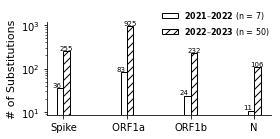

In [12]:
# counts per genome position (non-empty cells) — computed separately
print('this is Y1')
counts1 = (spike_df_spike.loc[Y1_seqs]  != "").sum().sum()
counts2 = (spike_df_ORF1a.loc[Y1_seqs] != "").sum().sum()
counts3 = (spike_df_ORF1b.loc[Y1_seqs] != "").sum().sum()
counts4 = (spike_df_N.loc[Y1_seqs] != "").sum().sum()

print('this is Y2')
counts5 = (spike_df_spike.loc[Y2_seqs]  != "").sum().sum()
counts6 = (spike_df_ORF1a.loc[Y2_seqs] != "").sum().sum()
counts7 = (spike_df_ORF1b.loc[Y2_seqs] != "").sum().sum()
counts8 = (spike_df_N.loc[Y2_seqs] != "").sum().sum()

# define ORF boundaries (amino acid positions)
regions_Y1 = {'Spike': counts1,
           ' ORF1a': counts2, 
           'ORF1b': counts3, 
           'N': counts4}

regions_Y2 = {'Spike': counts5,
           ' ORF1a': counts6, 
           'ORF1b': counts7, 
           'N': counts8}


# --- paired bar chart ---
labels = list(regions_Y1.keys())
x = np.arange(len(regions_Y1.keys()))
w = 0.1

fig, ax = plt.subplots(figsize=(4, 2))

b1 = ax.bar(np.arange(len(regions_Y1.keys())) - w/2, regions_Y1.values(), width=w, color="white", edgecolor="black",
            label=r"$\mathbf{2021–2022}$" + f" (n = {spike_df_spike.loc[Y1_seqs].shape[0]})")
b2 = ax.bar(np.arange(len(regions_Y2.keys())) + w/2, regions_Y2.values(), width=w, color="white",
            edgecolor="black", hatch="///",
            label=r"$\mathbf{2022–2023}$" + f" (n = {spike_df_spike.loc[Y2_seqs].shape[0]})")

for rect in b1:  # shift left bars slightly left
    h = rect.get_height()
    if h:
        ax.text(rect.get_x() + rect.get_width()/2 - 0.05, h + 0.5, str(int(h)),
                ha="center", va="bottom", fontsize=7)

for rect in b2:  # keep right bars centered
    h = rect.get_height()
    if h:
        ax.text(rect.get_x() + rect.get_width()/2, h + 0.5, str(int(h)),
                ha="center", va="bottom", fontsize=7)


ax.set_ylabel("# of Substitutions", fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(labels,  fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(fontsize=8, frameon=False,loc=(0.5,0.8))
ax.set_yscale('log')
plt.tight_layout()
plt.savefig("Alpha_Y1_Y2_all_four_partitions_substitution_counts10.png",
            dpi=1000, bbox_inches="tight")
